In [2]:
from vnstock import Vnstock
from pathlib import Path
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from tqdm import tqdm

In [3]:
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", None)

In [100]:
stock = Vnstock().stock()
industry = stock.listing.symbols_by_industries()

2025-06-02 15:12:58 - vnstock.common.vnstock - INFO - Mã chứng khoán không được chỉ định, chương trình mặc định sử dụng VN30F1M
2025-06-02 15:12:58 - vnstock.common.data.data_explorer - INFO - Không phải là mã chứng khoán, thông tin công ty và tài chính không khả dụng.


In [101]:
industry['icb_name2'].unique()

array(['Hàng & Dịch vụ Công nghiệp', 'Thực phẩm và đồ uống',
       'Truyền thông', 'Y tế', 'Hóa chất', 'Xây dựng và Vật liệu',
       'Công nghệ Thông tin', 'Dịch vụ tài chính', 'Bất động sản',
       'Hàng cá nhân & Gia dụng', 'Bán lẻ', 'Ngân hàng',
       'Điện, nước & xăng dầu khí đốt', 'Tài nguyên Cơ bản',
       'Du lịch và Giải trí', 'Ô tô và phụ tùng', 'Bảo hiểm', 'Dầu khí',
       'Viễn thông'], dtype=object)

In [ ]:
industry['icb_name3'].unique()

In [ ]:
industry['icb_name4'].unique()

In [104]:
def export_csv_stock_data(symbol_list, start, end, filename, add_vnindex=False):
    print(f'Bắt đầu thực hiện lấy dữ liệu từ {start} - {end} của các mã: {symbol_list}')
    data = pd.DataFrame()

    if add_vnindex:
        symbol_list.append('VNINDEX')

    success = []
    fail = []

    for symbol in tqdm(symbol_list):
        try:
            df_one_symbol = stock.quote.history(symbol=symbol, start=start, end=end, interval='1D')
            # df_one_symbol = stock.quote.history(symbol=symbol, start='2015-01-01', end='2025-05-31', interval='1D')
            time.sleep(1)
            
            df_one_symbol['symbol'] = symbol

            data = pd.concat([data, df_one_symbol], ignore_index=True)

            print(f'{symbol}: Success!')
            success.append(symbol)
        except Exception as e:
            print(f'{symbol}: Error {e}!')
            fail.append(symbol)

    print(f'Success {len(success)} : {success}')
    print(f'Fail {len(fail)} : {fail}')

    data.to_csv(filename, index=False)
    print(f'Đã lưu dữ liệu {symbol} vào file {filename}')


In [ ]:
data_info = {
    'start': '2015-01-01',
    'end': '2025-05-31',
    'add_vnindex': True,
    'industry_name_list': [
        'Bất động sản',
        'Ngân hàng',
        'Bán lẻ',
        'Xây dựng và Vật liệu'
    ],
    'filename': [
        'data_10_year_batdongsan.csv',
        'data_10_year_nganhang.csv',
        'data_10_year_banle.csv',
        'data_10_year_xaydung_vatlieu.csv',
    ]
}

In [ ]:
for idx, name in enumerate(data_info['industry_name_list']):
    df = industry[industry['icb_name2'] == name]
    symbol_list = df['symbol'].to_list()

    export_csv_stock_data(
        symbol_list, 
        data_info['start'], 
        data_info['end'], 
        data_info['filename'][idx], 
        add_vnindex=data_info['add_vnindex']
    )

## **Analysis**

In [73]:
data_batdongsan = pd.read_csv('data_10_year_batdongsan.csv')
data_nganhang = pd.read_csv('data_10_year_nganhang.csv')
data_banle = pd.read_csv('data_10_year_banle.csv')
data_xaydung_vatlieu = pd.read_csv('data_10_year_xaydung_vatlieu.csv')

In [74]:
# VNINDEX
df_vnindex = data_batdongsan[data_batdongsan['symbol'] == 'VNINDEX'].copy()
# Các ngành khác
df_bds = data_batdongsan[data_batdongsan['symbol'] != 'VNINDEX'].copy()
df_nh = data_nganhang[data_nganhang['symbol'] != 'VNINDEX'].copy()
df_bl = data_banle[data_banle['symbol'] != 'VNINDEX'].copy()
df_vlxd = data_xaydung_vatlieu[data_xaydung_vatlieu['symbol'] != 'VNINDEX'].copy()

all_data = {
    'batdongsan': df_bds,
    'nganhang': df_nh,
    'banle': df_bl,
    'vatlieuxaydung': df_vlxd
}

In [75]:
# Chỉnh type datetime -> set_index datetime
df_vnindex['time'] = pd.to_datetime(df_vnindex['time'])
df_vnindex.set_index('time', inplace=True)

for name, data in all_data.items():
    data['time'] = pd.to_datetime(data['time'])
    data.set_index('time', inplace=True)

In [22]:
for name, data in all_data.items():
    print('THÔNG TIN CƠ BẢN CỦA {name}: ')
    print(data.info())

THÔNG TIN CƠ BẢN CỦA {name}: 
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 267245 entries, 2017-06-14 to 2025-05-30
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   open    267245 non-null  float64
 1   high    267245 non-null  float64
 2   low     267245 non-null  float64
 3   close   267245 non-null  float64
 4   volume  267245 non-null  int64  
 5   symbol  267245 non-null  object 
dtypes: float64(4), int64(1), object(1)
memory usage: 14.3+ MB
None
THÔNG TIN CƠ BẢN CỦA {name}: 
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 49856 entries, 2015-01-05 to 2025-05-30
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    49856 non-null  float64
 1   high    49856 non-null  float64
 2   low     49856 non-null  float64
 3   close   49856 non-null  float64
 4   volume  49856 non-null  int64  
 5   symbol  49856 non-null  object 
dtypes: float64(4), i

In [64]:
for (method, group) in df_bds.groupby('symbol'):
    print(f'{method:10s} [{group.index.min()} - {group.index.max()}]       shape={group.shape}')

AAV        [2018-06-25 00:00:00 - 2025-05-30 00:00:00]       shape=(1732, 10)
AGG        [2020-01-09 00:00:00 - 2025-05-30 00:00:00]       shape=(1343, 10)
AMD        [2015-01-05 00:00:00 - 2024-07-25 00:00:00]       shape=(2376, 10)
API        [2015-01-05 00:00:00 - 2025-05-30 00:00:00]       shape=(2597, 10)
BCM        [2018-02-21 00:00:00 - 2025-05-30 00:00:00]       shape=(1810, 10)
BIG        [2022-01-10 00:00:00 - 2025-05-30 00:00:00]       shape=(842, 10)
BII        [2015-01-05 00:00:00 - 2025-05-30 00:00:00]       shape=(2422, 10)
BSC        [2015-01-05 00:00:00 - 2024-07-29 00:00:00]       shape=(2389, 10)
BVL        [2021-06-11 00:00:00 - 2025-05-30 00:00:00]       shape=(930, 10)
C21        [2015-01-05 00:00:00 - 2025-05-30 00:00:00]       shape=(2253, 10)
CCL        [2015-01-05 00:00:00 - 2025-05-30 00:00:00]       shape=(2597, 10)
CEO        [2015-01-05 00:00:00 - 2025-05-30 00:00:00]       shape=(2597, 10)
CK8        [2023-01-06 00:00:00 - 2024-07-25 00:00:00]       shape

In [77]:
# Chia theo group time
def classify_time(df: pd.DataFrame):
    group_time = {
        'Y': 'year',
        'Q': 'quarter',
        'M': 'month',
        'W': 'weekly'
    }

    for code, name in group_time.items():
        df[name] = df.index.to_period(code)
    
    df['weekday'] = df.index.day_name()

In [24]:
# Chia theo group close
def get_classify_close(df: pd.DataFrame, day):
    # Phải có day cố định 1 ngày vì gán label phụ thuộc vào mã
    df_with_day = df[df.index == day].copy().reset_index().drop(columns=['time'])

    df_with_day['close_level'] = pd.cut(
        df_with_day['close'], 
        bins=[0, 10, 20, 50, float('inf')],
        labels=['Low', 'Normal', 'High', 'Super High']
    )

    return df_with_day[['symbol', 'close_level']]

In [78]:
all_data_classify_close = {}
for name, data in all_data.items():
    classify_time(data)

    day = df_bds.index.max()
    all_data_classify_close[name] = get_classify_close(data, day)

In [26]:
# Xem ví dụ
print('--------------------- DATA HIỆN TẠI ---------------------')
print(df_bds.sample(5))

print('\n--------------------- DATA PHÂN LOẠI ---------------------')
print(all_data_classify_close['batdongsan'].sample(5))

--------------------- DATA HIỆN TẠI ---------------------
             open   high    low  close   volume symbol  year quarter    month  \
time                                                                            
2016-05-04   3.67   3.76   3.67   3.76     4100    API  2016  2016Q2  2016-05   
2024-09-26  13.85  13.90  13.65  13.70  2525508    IJC  2024  2024Q3  2024-09   
2023-08-28  10.80  11.20  10.55  11.20   500357    QCG  2023  2023Q3  2023-08   
2022-11-29   0.50   0.50   0.50   0.50        0    PXC  2022  2022Q4  2022-11   
2021-08-04  27.65  28.24  27.21  27.41  1950500    HDG  2021  2021Q3  2021-08   

                           weekly  
time                               
2016-05-04  2016-05-02/2016-05-08  
2024-09-26  2024-09-23/2024-09-29  
2023-08-28  2023-08-28/2023-09-03  
2022-11-29  2022-11-28/2022-12-04  
2021-08-04  2021-08-02/2021-08-08  

--------------------- DATA PHÂN LOẠI ---------------------
   symbol close_level
48    D11         Low
94    TIG         

In [27]:
def pie_chars(all_data, title="Tiêu đề chung"):
    ncols = 2
    nrows = (len(all_data) + 1) // 2
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, 10))
    axes = axes.flatten()

    for idx, (name, df) in enumerate(all_data.items()):
        ax = axes[idx]
        df_value_count = df['close_level'].value_counts().reset_index()
        colors = plt.get_cmap('Blues')(np.linspace(0.2, 0.7, len(df['close_level'].unique())))

        wedges, texts, autotexts = ax.pie(
            df_value_count['count'], 
            colors=colors, 
            autopct='%1.1f%%', 
            wedgeprops={"linewidth": 1, "edgecolor": "white"}
        )

        ax.legend(
            wedges,
            df_value_count['close_level'],
            title="Close Level",
            # loc='upper left',
            bbox_to_anchor=(1, 1)
        )

        ax.set_title(name.upper())
        plt.setp(autotexts, size=8, weight="bold")
    
    plt.suptitle(title.upper(), fontsize=18)
    # Chừa chỗ phía trên để không bị tiêu đề đè lên subplot
    plt.tight_layout(rect=[0, 0, 1, 0.98])  # Chừa 2% trên cùng cho tiêu đề
    plt.show()

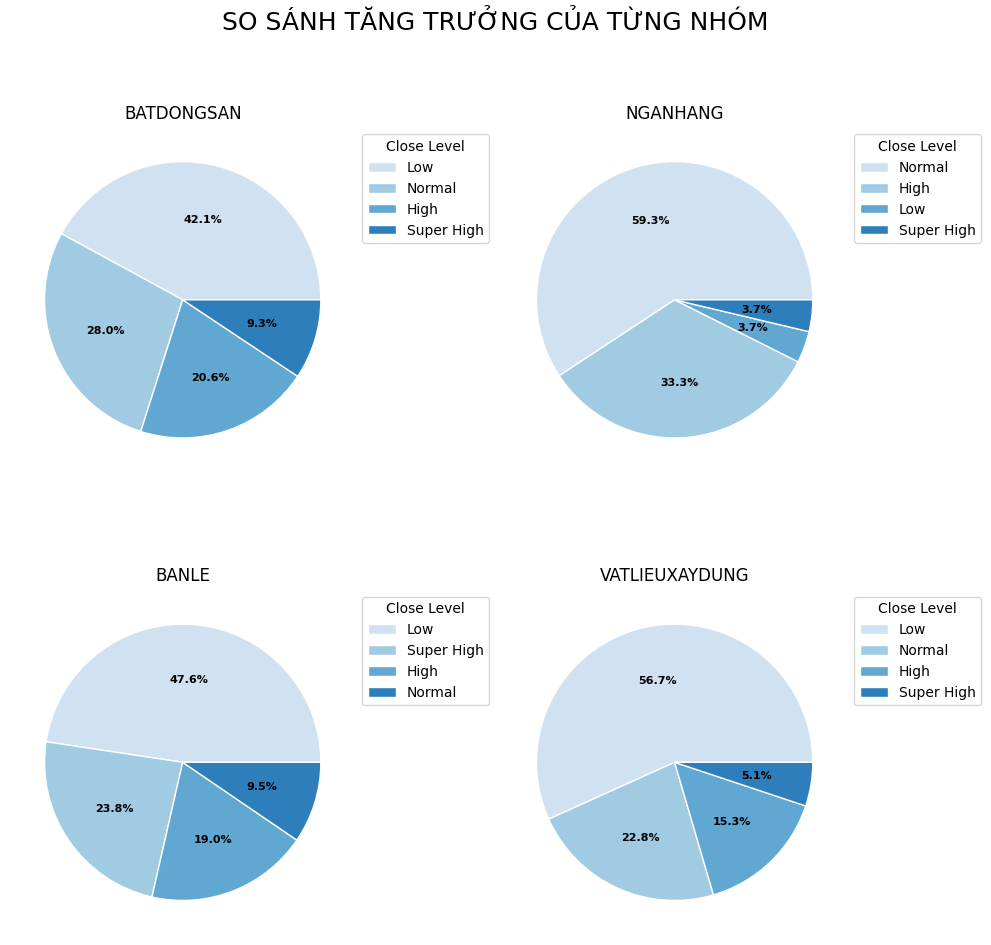

In [28]:
# Kiểm tra tỉ lệ của các label close
pie_chars(all_data_classify_close, 'So sánh tăng trưởng của từng nhóm')

In [ ]:
symbols_to_remove = all_data_classify_close['batdongsan'].loc[all_data_classify_close['batdongsan']['close_level'] == 'Low', 'symbol'].to_list()
df_bds = df_bds[~df_bds['symbol'].isin(symbols_to_remove)]
df_bds['symbol'].value_counts()

symbol
HDC    2597
HDG    2597
CEO    2597
HLD    2597
ITC    2597
       ... 
SZG     847
LSG     762
CK8     385
TAL     343
MBT      46
Name: count, Length: 84, dtype: int64

In [123]:
# % tăng giảm liên tiếp từng ngày 
def growth_pct_change(close: pd.Series):
    return close.pct_change() * 100

# % tăng giảm so với ngày đầu
def cumulative_growth_from_start(close: pd.Series):
    return (close - close.iloc[0]) * 100 / close.iloc[0]

# Hàm để apply group
def apply_growth(df: pd.DataFrame):
    df['pct_change'] = growth_pct_change(df.sort_index().loc[:, 'close'])
    df['pct_change'].fillna(value=0, inplace=True)
    df['cumulative_growth'] = cumulative_growth_from_start(df.sort_index().loc[:, 'close'])
    return df

In [ ]:
# Kiểm tra về bất động sản trước
# Tính tăng trưởng của cả giai đoạn 
df_bds_test = df_bds.copy()
df_bds_test = df_bds_test[df_bds_test['close'] != 0]
df_bds_test = df_bds_test.groupby('symbol').apply(apply_growth)
df_bds_test.head(5)

open   high    low  close  volume symbol  year quarter  \
symbol time                                                                  
AGG    2020-01-09  21.02  21.02  21.02  21.02  403500    AGG  2020  2020Q1   
       2020-01-10  15.54  15.95  15.49  15.49  382330    AGG  2020  2020Q1   
       2020-01-13  15.54  15.57  15.36  15.36  263410    AGG  2020  2020Q1   
       2020-01-14  15.23  15.23  14.90  15.03  573820    AGG  2020  2020Q1   
       2020-01-15  15.00  15.16  15.00  15.11  228400    AGG  2020  2020Q1   

                     month                 weekly    weekday month_day  \
symbol time                                                              
AGG    2020-01-09  2020-01  2020-01-06/2020-01-12   Thursday     01-09   
       2020-01-10  2020-01  2020-01-06/2020-01-12     Friday     01-10   
       2020-01-13  2020-01  2020-01-13/2020-01-19     Monday     01-13   
       2020-01-14  2020-01  2020-01-13/2020-01-19    Tuesday     01-14   
       2020-01-15  2020-01  2020-01-13/2020-01-19  Wednesday     01-15   

                   pct_change  cumulative_growth  
symbol time                                       
AGG    2020-01-09    0.000000           0.000000  
       2020-01-10  -26.308278         -26.308278  
       2020-01-13   -0.839251         -26.926736  
       2020-01-14   -2.148438         -28.496670  
       2020-01-15    0.532269         -28.116080

In [140]:
df_bds_test.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 172666 entries, ('AGG', Timestamp('2020-01-09 00:00:00')) to ('XDH', Timestamp('2025-05-30 00:00:00'))
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype        
---  ------             --------------   -----        
 0   open               172666 non-null  float64      
 1   high               172666 non-null  float64      
 2   low                172666 non-null  float64      
 3   close              172666 non-null  float64      
 4   volume             172666 non-null  int64        
 5   symbol             172666 non-null  object       
 6   year               172666 non-null  period[Y-DEC]
 7   quarter            172666 non-null  period[Q-DEC]
 8   month              172666 non-null  period[M]    
 9   weekly             172666 non-null  period[W-SUN]
 10  weekday            172666 non-null  object       
 11  month_day          172666 non-null  object       
 12  pct_change         172666 non-null  flo

In [160]:
def plot_growth(df: pd.DataFrame):
    plt.figure(figsize=(15, 6))

    plt.plot(df['time'], df['cumulative_growth'])

    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.gcf().autofmt_xdate()

    # plt.title('Biến động tăng giảm theo ngày bất động sản', fontsize=16)

    # Bật lưới
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

    # Thêm bảng chú thích (legend)
    plt.legend(loc='upper left')  # Đặt bên phải đồ thị

    plt.tight_layout()  # Căn chỉnh tránh bị cắt
    plt.show()

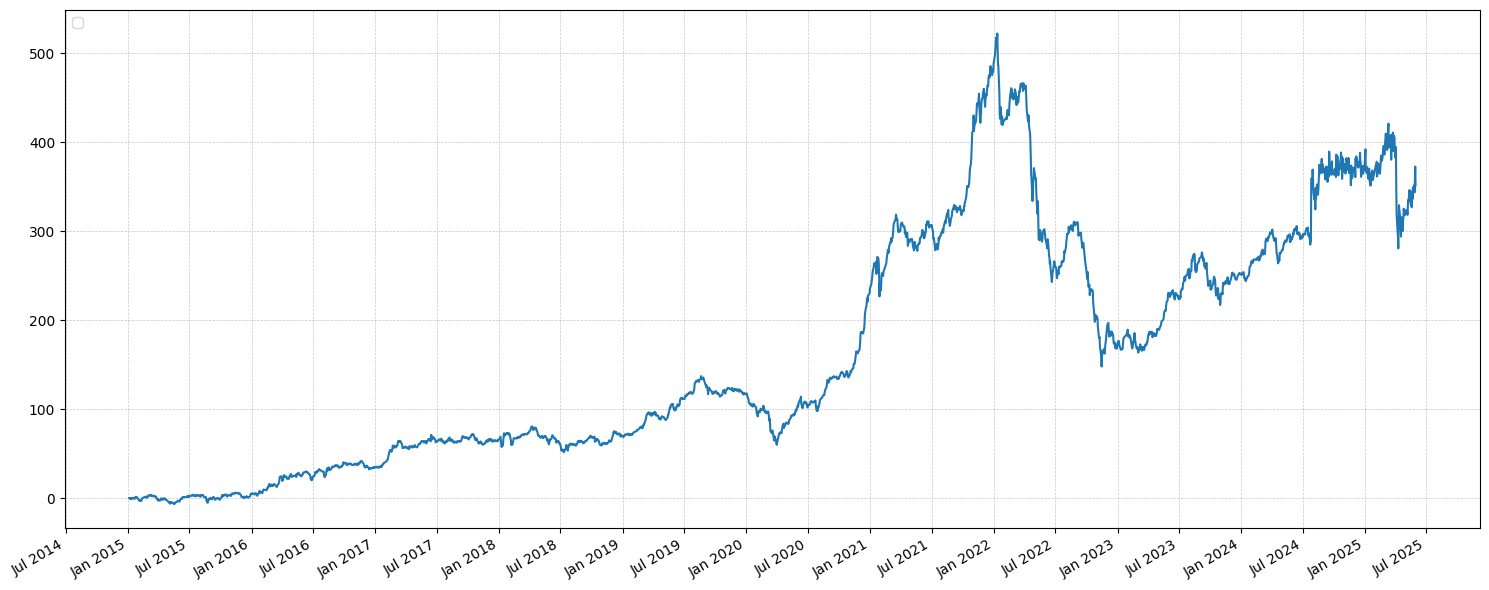

In [161]:
full_time = df_bds_test.groupby(level='time')['cumulative_growth'].mean().reset_index()
plot_growth(full_time)

In [227]:
def calc_up_down_stock_value(df: pd.DataFrame):
    stock_up_count = (df['pct_change'] > 0).sum()
    stock_down_count = (df['pct_change'] < 0).sum()
    neutral_count = (df['pct_change'] == 0).sum()
    # Trả về một Series, tên của Series (index) sẽ là tên cột trong kết quả
    return pd.Series({
        'stock_up': stock_up_count,
        'stock_down': stock_down_count,
        'neutral': neutral_count
    })
df_year_2024 = df_bds_test[df_bds_test['year'] == '2024'].copy()
up_down_stock = df_year_2024.groupby(df_year_2024.index.get_level_values('time')).apply(calc_up_down_stock_value)
up_down_stock = up_down_stock.iloc[1:] # Xóa dòng đầu vì full 0 và neutral hết

In [228]:
test = up_down_stock

In [234]:
up_down_stock = test

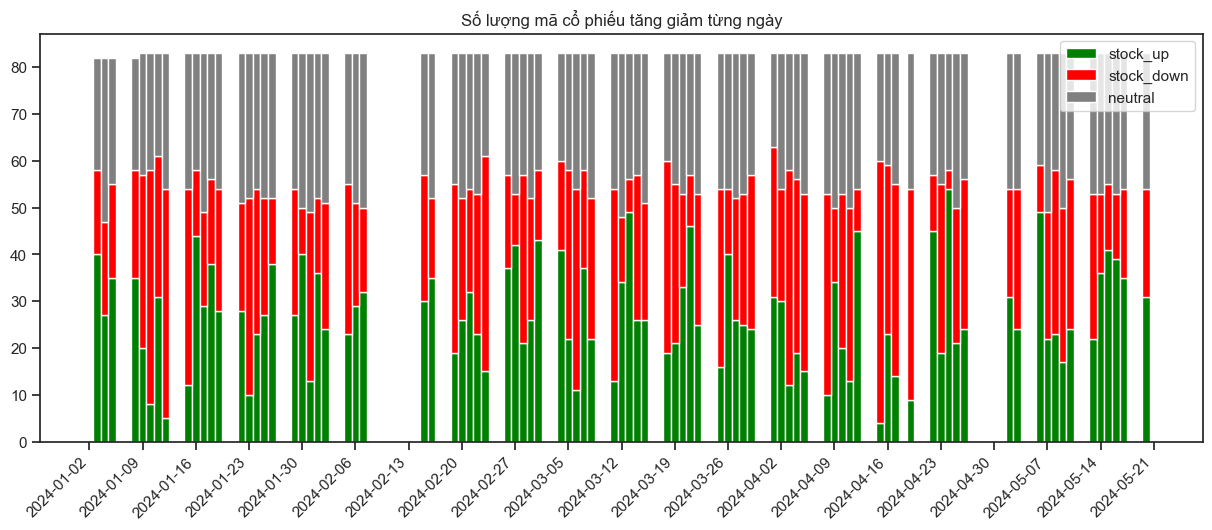

In [237]:
up_down_stock = up_down_stock[0:90]
# Chiều ngang dài tự do theo số dòng (ngày)
# n_days = up_down_stock.shape[0]
# fig_width = max(10, n_days * 0.3)  # mỗi ngày chiếm 0.3 inch, tùy chỉnh nếu cần

fig, ax = plt.subplots(figsize=(15, 6))

colors = {
    'stock_up': 'green',
    'stock_down': 'red',
    'neutral': 'gray'
}
bottom = np.zeros(up_down_stock.shape[0])
width = 1

for col_name, col_series in up_down_stock.items():
    p = ax.bar(up_down_stock.index, col_series.values, width, label=col_name, bottom=bottom, color=colors[col_name])
    bottom += col_series

ax.set_title("Số lượng mã cổ phiếu tăng giảm từng ngày")
ax.legend(loc="upper right")

# Xử lý trục thời gian
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate(rotation=45)

plt.show()

In [163]:
df_bds_test['month_day'] = df_bds_test.index.get_level_values('time').strftime('%m-%d')

In [166]:
# df_bds_test['year'] = df_bds_test.index.get_level_values('time').dt.year.astype(str)

pivot_df = (
    df_bds_test
    .groupby(['year', 'month_day'])['cumulative_growth']
    .mean()
    .reset_index()
)

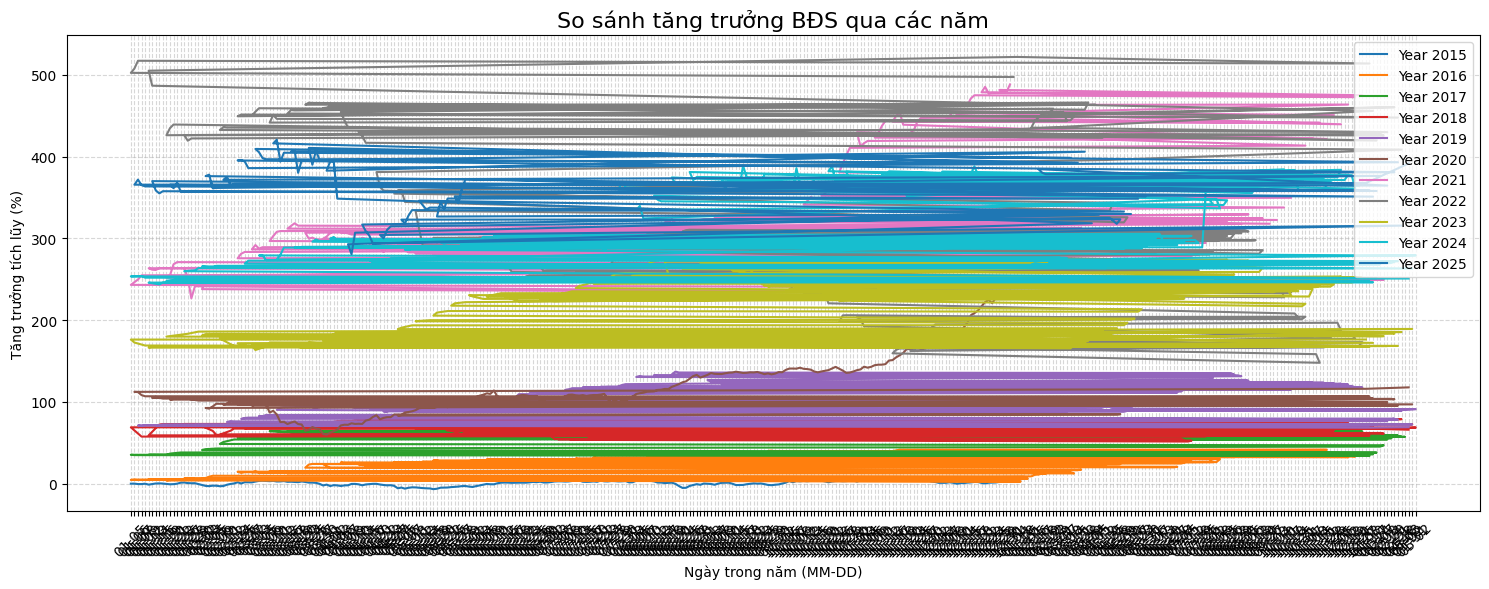

In [168]:
plt.figure(figsize=(15, 6))

for year in sorted(pivot_df['year'].unique()):
    df_plot = pivot_df[pivot_df['year'] == year]
    plt.plot(df_plot['month_day'], df_plot['cumulative_growth'], label=f'Year {year}')

plt.title('So sánh tăng trưởng BĐS qua các năm', fontsize=16)
plt.xlabel('Ngày trong năm (MM-DD)')
plt.ylabel('Tăng trưởng tích lũy (%)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

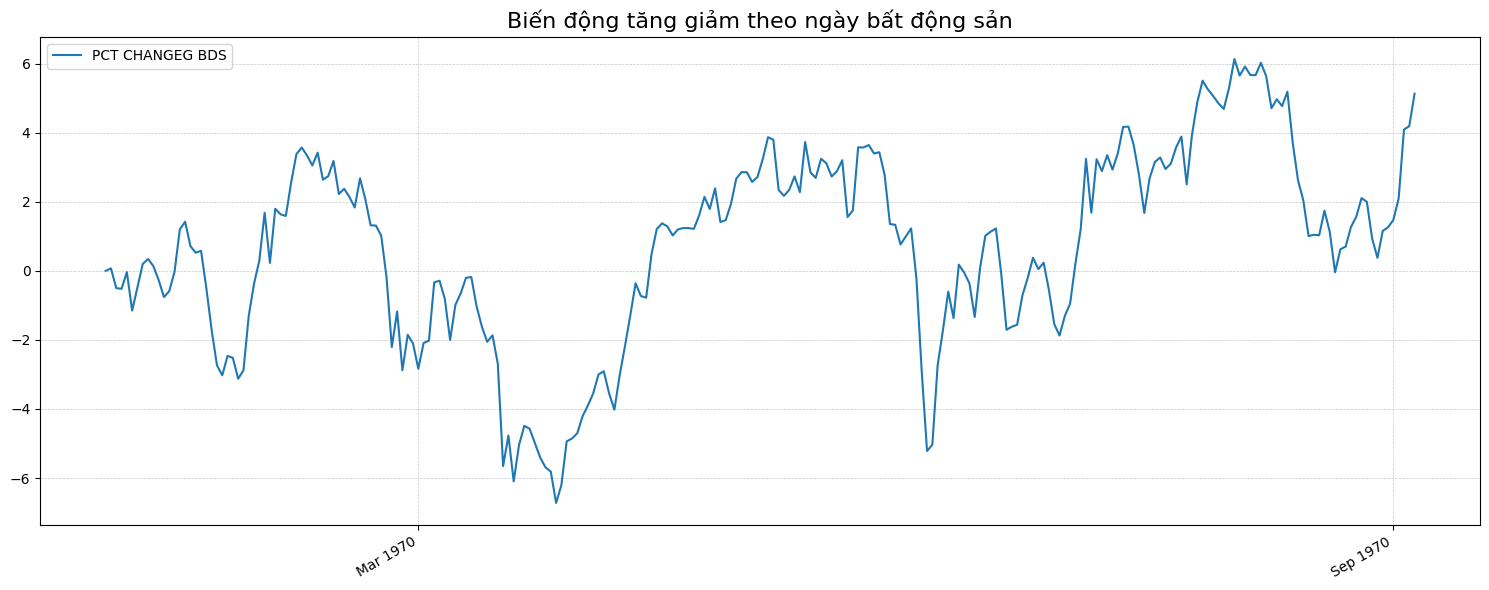

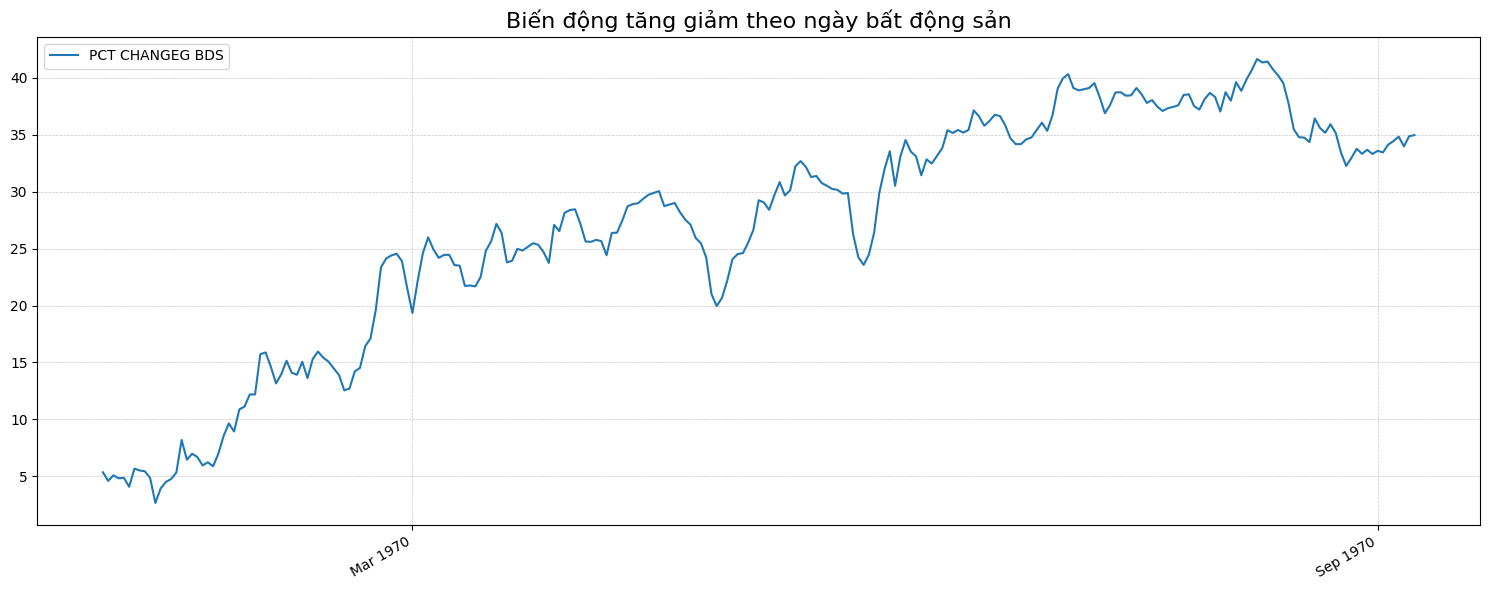

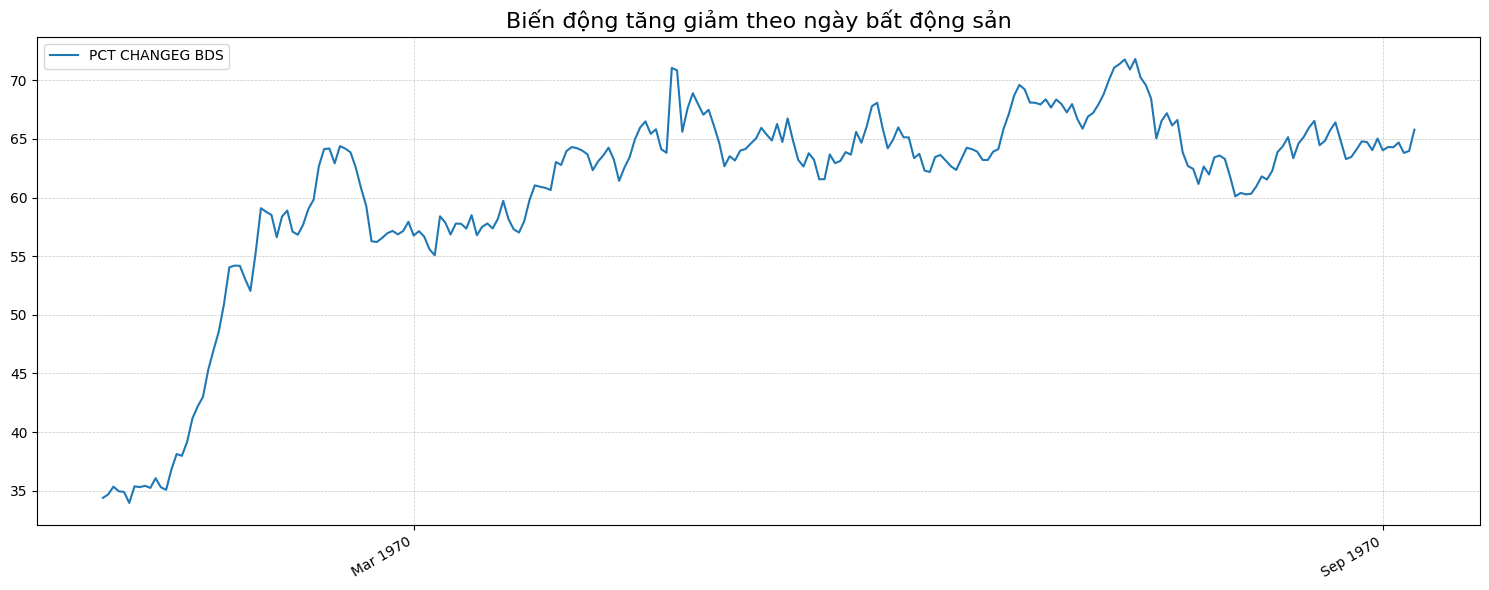

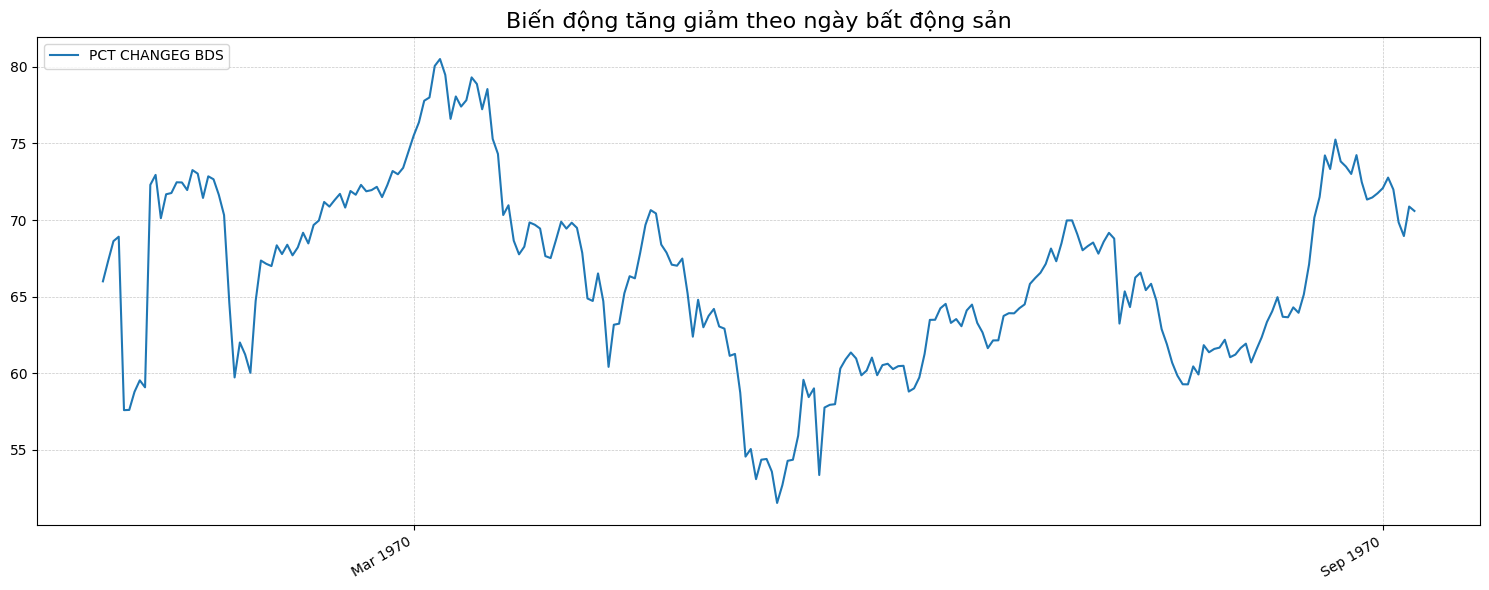

In [ ]:
for data in [year_1, year_2, year_3, year_4]:
    plt.figure(figsize=(15, 6))
    
    plt.plot(data['month_day'], data['cumulative_growth'], label='PCT CHANGEG BDS')

    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.gcf().autofmt_xdate()

    plt.title('Biến động tăng giảm theo ngày bất động sản', fontsize=16)

    # Bật lưới
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

    # Thêm bảng chú thích (legend)
    plt.legend(loc='upper left')  # Đặt bên phải đồ thị

    plt.tight_layout()  # Căn chỉnh tránh bị cắt
    plt.show()

In [ ]:
def growth_index(close):
    # return close.pct_change() * 100
    return (close - close.iloc[0]) * 100 / close.iloc[0]

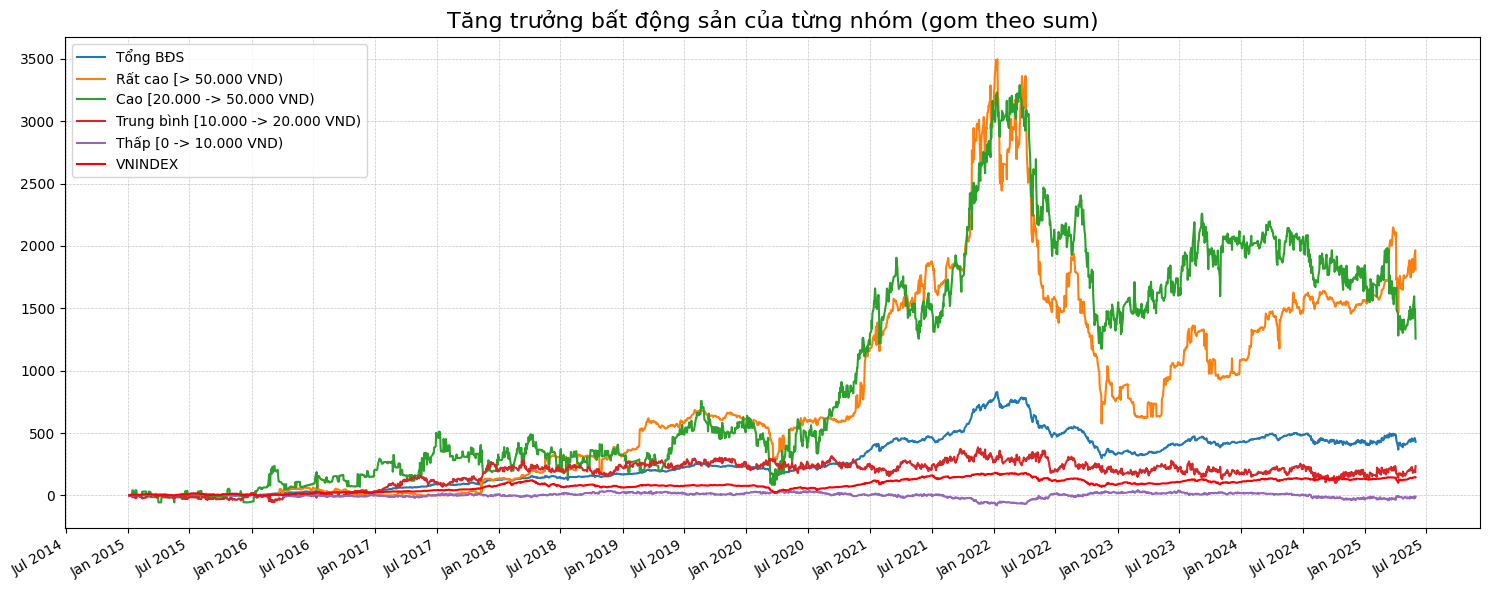

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(sum_batdongsan['time'], growth_index(sum_batdongsan['close']), label='Tổng BĐS')
plt.plot(sum_batdongsan_super_high['time'], growth_index(sum_batdongsan_super_high['close']), label='Rất cao [> 50.000 VND)')
plt.plot(sum_batdongsan_high['time'], growth_index(sum_batdongsan_high['close']), label='Cao [20.000 -> 50.000 VND)')
plt.plot(sum_batdongsan_normal['time'], growth_index(sum_batdongsan_normal['close']), label='Trung bình [10.000 -> 20.000 VND)')
plt.plot(sum_batdongsan_low['time'], growth_index(sum_batdongsan_low['close']), label='Thấp [0 -> 10.000 VND)')
plt.plot(df_vnindex.index, growth_index(df_vnindex['close']), color='red', label='VNINDEX')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gcf().autofmt_xdate()

plt.title(f"Tăng trưởng bất động sản của từng nhóm (gom theo sum)", fontsize=16)

# Bật lưới
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Thêm bảng chú thích (legend)
plt.legend(loc='upper left')  # Đặt bên phải đồ thị

plt.tight_layout()  # Căn chỉnh tránh bị cắt
plt.show()

In [ ]:
# Phân tích từng nhóm với chung
# Phân tích so sánh các năm của toàn bộ
# Phân tích so sánh rollwindow của 2-3-4 năm
# Phân tích năm chẵn, năm lẻ
# Phân tích quý tương tự vậy, so sánh quý này của năm này với quý này năm kia
# Phân tích quý này 

In [ ]:
# --- 3. Phương pháp IQR (Interquartile Range) ---
print("\n--- Phương pháp IQR ---")
iqr_multiplier = 1.5 # Hệ số nhân IQR (1.5 cho outlier, 3 cho extreme outlier)

last_day = df_bds.index.max()
df_check_IQR = df_bds.loc[(df_bds.index == last_day), ['symbol', 'close']].copy().reset_index().drop(columns=['time'])
print(df_check_IQR)
# for value in df_check_IQR['close'].to_list():
    # print(df_bds[value])
Q1 = df_check_IQR['close'].quantile(0.25)
Q3 = df_check_IQR['close'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - iqr_multiplier * IQR
upper_bound = Q3 + iqr_multiplier * IQR

outliers_iqr = df_check_IQR.loc[(df_check_IQR['close'] < lower_bound) | (df_check_IQR['close'] > upper_bound), ['symbol', 'close']]

print(f"\nOutliers trong cột '{'close'}' sử dụng IQR (hệ số={iqr_multiplier}):")
print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"  Giới hạn dưới: {lower_bound:.2f}, Giới hạn trên: {upper_bound:.2f}")
if not outliers_iqr['close'].empty:
    print(outliers_iqr['symbol'].unique())
    print(outliers_iqr['close'].unique())


--- Phương pháp IQR ---
    symbol  close
0      LEC   5.30
1      DXS   7.12
2      XDH  17.30
3      HDC  25.35
4      HDG  26.20
..     ...    ...
102    VRE  27.50
103    VPH   5.05
104    VRC  12.70
105    VPI  53.40
106    VRG  18.70

[107 rows x 2 columns]

Outliers trong cột 'close' sử dụng IQR (hệ số=1.5):
  Q1: 5.49, Q3: 26.25, IQR: 20.76
  Giới hạn dưới: -25.65, Giới hạn trên: 57.39
['BCM' 'SSH' 'NTC' 'KSF' 'VHM' 'SJS' 'SIP' 'VIC' 'VEF']
[ 60.6  87.6 157.   66.3  77.6  86.6  68.6  98.4 222. ]


Text(0.5, 1.0, 'Distribution of Price')

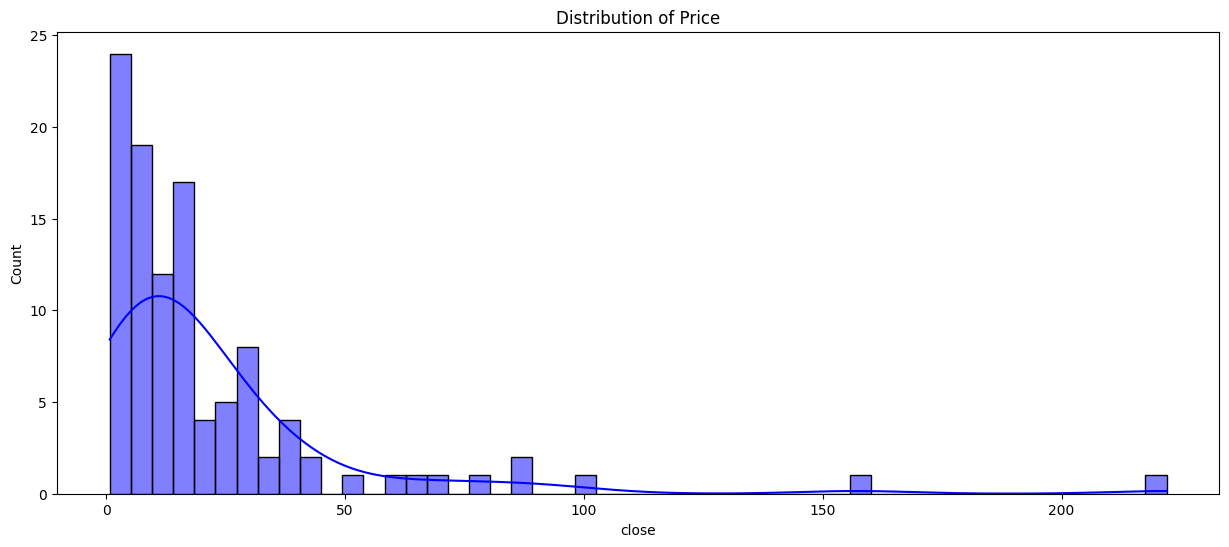

In [ ]:
plt.figure(figsize=(15, 6))
sns.histplot(df_check_IQR['close'], kde=True, color='blue', bins=50)
plt.title('Distribution of Price')
